# Comparing Open-Access Museum Collections: The Met vs. the Art Institute of Chicago

## Introduction

**This project compares the open-access collections of the Metropolitan Museum of Art and the Art Institute of Chicago to understand how each museum represents art across origin, time period, classification, and medium. The primary audience is museum curators, museum directors, and art enthusiasts who want a clearer view of how these institutions differ in the breadth and depth of their digitized holdings.**

**The analysis is motivated by a simple question: when two major museums make large portions of their collections publicly accessible, what patterns become visible in the kinds of objects they preserve and present? To answer that question, this report combines SQL and Python to examine collection composition, historical coverage, and relationships across multiple variables rather than relying on simple item counts alone.**

**The project focuses on four main questions: which origins and classifications are most represented in each museum, how representation changes across historical periods, whether certain origins are concentrated in specific object types or mediums, and how well basic collection features help predict origin categories in a simple classification model. Together, these sections aim to show not just what each museum holds, but how each collection is structured.**

## Importing Libraries

In [1]:
import requests
import json
import glob
from pprint import pprint
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from time import sleep
import re


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix

**The Met and the Art Institute of Chicago have over 1.5 million and 300,000 items in their complete collections respectively. Through an Open Access Initiative to make their collections more accessible to the general public, they each have digitized a portion of their collections, accessible via Github. Here we access the AIC's works through a folder of json files, and the Met's through a csv that consolidates all works onto one file, creating dataframes for each.**

In [2]:
files = glob.glob("artworks/*.json")

all_data = []

for file in files:
    with open(file, 'r') as f:
        data = json.load(f)
        all_data.append(data)

full_aic_df = pd.DataFrame(all_data)

In [3]:
full_met_df = pd.read_csv("MetObjects.csv", engine="python",on_bad_lines="skip")

**Each museum's data contains a large multitude of columns describing the works. For the purposes of this analysis, we are keeping a select few, particularly those that are shared amongst the two museums.**

In [4]:
columns_to_keep_aic = [
    "id",
    "title",
    "has_not_been_viewed_much",
    "is_on_view",
    "artist_title",
    "artist_display",
    "classification_title",
    "artwork_type_title",
    "department_title",
    "medium_display",
    "date_display",
    "date_start",
    "date_end",
    "fiscal_year",
    "place_of_origin",
]

columns_to_keep_met = [
    "Object ID",
    "Is Highlight",
    "Department",
    "Title",
    "Artist Display Name",
    "Object Begin Date",
    "Object End Date",
    "Artist Nationality",
    "Medium",
    "Classification",
    "AccessionYear",
    "Object Name"
]

temp_aic = full_aic_df[columns_to_keep_aic]

temp_met = full_met_df[columns_to_keep_met]

In [5]:
temp_aic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1587 entries, 0 to 1586
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        1587 non-null   int64  
 1   title                     1587 non-null   str    
 2   has_not_been_viewed_much  1587 non-null   bool   
 3   is_on_view                1507 non-null   object 
 4   artist_title              1373 non-null   str    
 5   artist_display            1583 non-null   str    
 6   classification_title      1571 non-null   str    
 7   artwork_type_title        1551 non-null   str    
 8   department_title          1506 non-null   str    
 9   medium_display            1583 non-null   str    
 10  date_display              1579 non-null   str    
 11  date_start                1532 non-null   float64
 12  date_end                  1532 non-null   float64
 13  fiscal_year               1011 non-null   float64
 14  place_of_origin    

In [6]:
missing_aic = pd.DataFrame({
    "missing_count": temp_aic.isna().sum(),
    "percent_missing": temp_aic.isna().mean() * 100
}).sort_values("percent_missing", ascending=False)

missing_aic

,missing_count,percent_missing
fiscal_year,576,36.294896
artist_title,214,13.484562
place_of_origin,113,7.120353
department_title,81,5.103970
is_on_view,80,5.040958
date_end,55,3.465658
date_start,55,3.465658
artwork_type_title,36,2.268431
classification_title,16,1.008192
date_display,8,0.504096


In [7]:
temp_met.info()

<class 'pandas.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Object ID            484956 non-null  int64
 1   Is Highlight         484956 non-null  bool 
 2   Department           484956 non-null  str  
 3   Title                456153 non-null  str  
 4   Artist Display Name  282513 non-null  str  
 5   Object Begin Date    484956 non-null  int64
 6   Object End Date      484956 non-null  int64
 7   Artist Nationality   282513 non-null  str  
 8   Medium               477741 non-null  str  
 9   Classification       406239 non-null  str  
 10  AccessionYear        481094 non-null  str  
 11  Object Name          482690 non-null  str  
dtypes: bool(1), int64(3), str(8)
memory usage: 101.0 MB


In [8]:
missing_met = pd.DataFrame({
    "missing_count": temp_met.isna().sum(),
    "percent_missing": temp_met.isna().mean() * 100
}).sort_values("percent_missing", ascending=False)

missing_met

,missing_count,percent_missing
Artist Nationality,202443,41.744612
Artist Display Name,202443,41.744612
Classification,78717,16.231782
Title,28803,5.939302
Medium,7215,1.487764
AccessionYear,3862,0.796361
Object Name,2266,0.467259
Object ID,0,0.000000
Department,0,0.000000
Is Highlight,0,0.000000


## Data Cleaning

**In a previous EDA done on a smaller portion of the AIC's collection, a set of steps were necessary to handle data entry mishandling. The include adjusting data to allow for realistic dates and normalization of countries that will make later analysis easier**

**To start, under the assumption that some data entries could be placeholder values, we cast any unbelievable dates, (e.g artworks dated to start or end later than 2026 or start early than 10000 BC) to be null rather than hold values that would affect statistics.**

In [9]:
temp_aic.loc[temp_aic["date_end"] > 2026, "date_end"] = pd.NA
temp_aic.loc[temp_aic["date_start"] > 2026, "date_start"] = pd.NA
temp_aic.loc[temp_aic["date_start"] < -10000, "date_start"]= pd.NA

temp_met.loc[temp_met["Object End Date"] > 2026, "Object End Date"] = pd.NA
temp_met.loc[temp_met["Object Begin Date"] > 2026, "Object Begin Date"] = pd.NA
temp_met.loc[temp_met["Object Begin Date"] < -10000, "Object Begin Date"]= pd.NA

**Similarly, for later analysis we wish to consolidate certain places of origin to be broader countries and regions rather than cities and neighborhoods. For the AIC, code is reused from the previous EDA to cast the most commonly mentioned cities to their corresponding countries. As there are thousands of unique regions in the entire EDA, only frequently seen regions are cleaned.**

In [10]:
temp_aic["place_of_origin"] = (temp_aic["place_of_origin"].str.strip().str.title())
city_to_country = {
    # France
    "Paris": "France",
    "Versailles": "France",
    "Lyon": "France",
    "Baccarat": "France",
    "Saint-Louis-Lès-Bitche": "France",
    "Lunéville": "France",
    "Clichy": "France",
    

    # Italy
    "Florence": "Italy",
    "Rome": "Italy",
    "Venice": "Italy",
    "Milan": "Italy",

    # United Kingdom
    "London": "United Kingdom",
    "Oxford": "United Kingdom",
    "Cambridge": "United Kingdom",
    "England": "United Kingdom",

    # Germany
    "Berlin": "Germany",
    "Munich": "Germany",
    "Nuremberg": "Germany",

    # Spain
    "Madrid": "Spain",
    "Barcelona": "Spain",

    # Netherlands
    "Amsterdam": "Netherlands",
    "Haarlem": "Netherlands",
    "Holland": "Netherlands",

    # United States
    "New York City": "United States",
    "Boston": "United States",
    "Chicago": "United States",

    # Japan
    "Kyoto": "Japan",
    "Tokyo": "Japan",

    # China
    "Beijing": "China",
    "Shanghai": "China",
    
    # Belgium
    "Flanders": "Belgium"
}

def normalize_origin(place):
    if pd.isna(place):
        return None

    if place in city_to_country:
        return city_to_country[place]

    return place

temp_aic["origin_normalized"] = temp_aic["place_of_origin"].apply(normalize_origin)

**For the Met, they have categories to describe artworks on the city, country, and region levels, along with other specific categories (ex. Rivers). Because specific sourcing of works ranges (some works may be credited to a country without a city, or a region without a country) there are several thousand missing values for each category. To fix this, we will base the origin of an artwork on the credited nationality of the artist. First, we create a dictionary that maps nationalities to countries, and then create a function to strip nationalities into smaller chunks of strings to circumvent abnormal formatting. the normalize_origin function is then applied to the dataframe.**

In [11]:
nationality_to_country = {
    "American": "United States",
    
    "British": "United Kingdom",
    "English": "United Kingdom",
    "Scottish": "United Kingdom",
    
    "French": "France",
    
    "Italian": "Italy",
    
    "German": "Germany",
    
    "Spanish": "Spain",
    
    "Dutch": "Netherlands",
    "Netherlandish": "Netherlands",
    
    "Belgian": "Belgium",
    "Flemish": "Belgium",
    
    "Mexican": "Mexico",
    
    "Japanese": "Japan",
    
    "Chinese": "China",
    
    "Austrian": "Austria",
    
    "Egyptian": "Egypt"
}

def normalize_origin(place):

    if pd.isna(place):
        return None

    parts = [x.strip() for x in re.split(r'\s*[|,]\s*', place) if x.strip()]

    if len(parts) == 0:
        return None

    place = parts[0]

    return nationality_to_country.get(place, place)


temp_met["origin_normalized"] = temp_met["Artist Nationality"].apply(normalize_origin)

**The previous AIC EDA revealed that formatting dates into century categories aided future analysis. So, for each museum, arithmetic is performed on the start dates of works to extract what century they belong to, which are then turned into strings. Each century from the 11th to 21st are created, with a large bucket holding any works that were created before the year 1000.**

In [12]:
#AIC CENTURIES
temp_aic["century_num"] = ((temp_aic["date_start"] - 1) // 100) + 1

# Step 2: text label column (for plotting)
temp_aic["century_label"] = temp_aic["century_num"].astype("Int64").astype(str) + "th century"

# Step 3: group very old dates and cleaning
temp_aic.loc[temp_aic["date_start"] > 2000, "century_label"] = "21st century"
temp_aic.loc[temp_aic["date_start"] < 1000, "century_label"] = "Before 1000"
temp_aic.loc[temp_aic["century_label"] == "<NA>th century", "century_label"] = "Non Specific Dates"


#MET CENTURIES
temp_met["century_num"] = ((temp_met["Object Begin Date"] - 1) // 100) + 1

# Step 2: text label column (for plotting)
temp_met["century_label"] = temp_met["century_num"].astype("Int64").astype(str) + "th century"

# Step 3: group very old dates and cleaning
temp_met.loc[temp_met["Object Begin Date"] > 2000, "century_label"] = "21st century"
temp_met.loc[temp_met["Object Begin Date"] < 1000, "century_label"] = "Before 1000"
temp_met.loc[temp_met["century_label"] == "<NA>th century", "century_label"] = "Non Specific Dates"

**Later on, the museums will be combined into one large dataframe for specific analysis. For clarity, an additional column is created labeling which museum a row to.**

In [13]:
temp_aic['museum'] = 'AIC'
temp_met['museum'] = 'Met'

## Test/Train Splitting

**Later in our analysis, logistic regressions will be performed to predict the probability of a work being popular. To avoid biases in our univariate and multivariate analysis further altering our data, we will create a test/train split of our dataframes. Future analysis will be performed on the training data for each museum as the test dataframe will be reserved for validation of our models.**

In [14]:
aic_train, aic_test = train_test_split(
    temp_aic,
    test_size=0.2,
    random_state=42
)

met_train, met_test = train_test_split(
    temp_met,
    test_size=0.2,
    random_state=42
)

In [15]:
print("AIC train = ", aic_train.shape)
print("Met train = ", met_train.shape)
print("\nAIC test = ", aic_test.shape)
print("Met test = ", met_test.shape)

AIC train =  (1269, 19)
Met train =  (387964, 16)

AIC test =  (318, 19)
Met test =  (96992, 16)


## Univariate Analysis

### AIC

#### **Century Analysis**

**Using our previously formed century labels, we can plot and view the distribution of centuries for works in the AIC.**

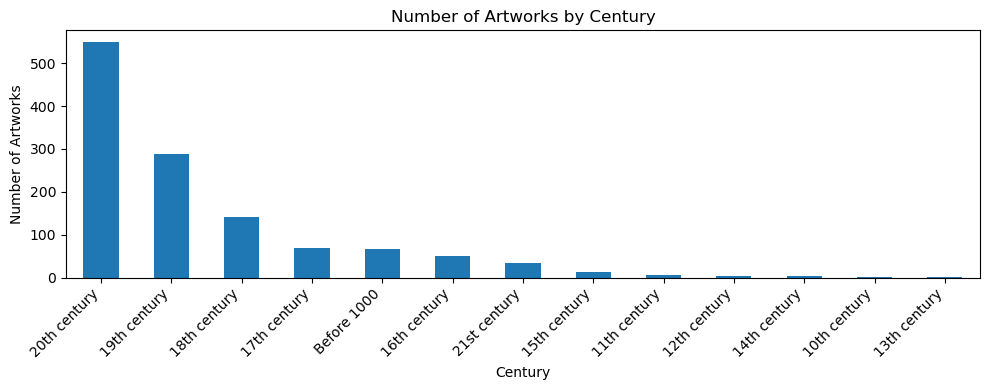

In [16]:
aic_train["century_label"].value_counts().plot(kind="bar", figsize=(10,4))
plt.title("Number of Artworks by Century")
plt.ylabel("Number of Artworks")
plt.xlabel("Century")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Our findings are similar to previous findings where the 20th, 19th, and 18th century are the most represented in the museum's collection. There is a similar dramatic falling in representation of other works, but our previous subset of data saw more inclusion of pieces from the 21st century than those older.As a research institution, much of the AIC's collection thus prioritizes older eras to contribute to the canon of art history. Meanwhile, in the 21st century, only 25 years have transpired, naturally leading to a large drop in works.**

**There is a relatively significant portion of works without specific dates attributed to them. Throguhout their website, the AIC states that they value accuracy in their research. While estimates on a work's year of conception are possible, the resources needed to find specific dates is likely less easily accessible.**

#### Place of Origin Analysis

**As a research institution, the AIC is particular in their system of confirming the place of origin or works. Previously, in the Data Cleaning Section, we consolidated many specific regions to be attributed to larger countries. However, in investigating the proportion of null values in the original place_of_origin column:**

In [17]:
aic_train["place_of_origin"].isna().mean()

np.float64(0.07722616233254531)

**We see that 7% of the Open Access collection is null. Many of their artworks are prodcured by donations from personal collections or generally have long histories of loans across institutions that lead to their origins being unknown. In an effort to relay reliable information, this leads to such a large amount (approximately 7,000 works of our training subset) to be described as having no origin.**

**Using our previously created origin_normalized column, we can analyze the distribution of which regions are represented by the AIC.**

In [18]:
aic_train["origin_normalized"].value_counts(normalize=True).head(10)

origin_normalized
United States     0.344150
France            0.136635
Japan             0.112724
United Kingdom    0.067464
Italy             0.043553
Germany           0.035867
Netherlands       0.032451
China             0.030743
Egypt             0.011102
Spain             0.010248
Name: proportion, dtype: float64

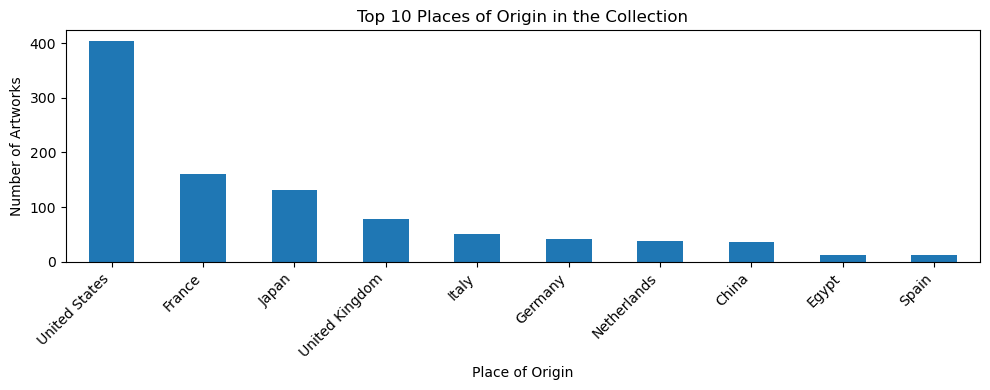

In [19]:
top_places = aic_train["origin_normalized"].value_counts().head(10)

top_places.plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 Places of Origin in the Collection")
plt.ylabel("Number of Artworks")
plt.xlabel("Place of Origin")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**As shown in the chart, the United States accounts for a substantially larger number of artworks than any other country, with France, Japan, and the United Kingdom representing the next most common origins but at significantly lower counts. This pattern likely reflects both the museum’s geographic location and its historical collecting priorities, as American museums have traditionally emphasized acquiring works by domestic artists alongside major European traditions. The presence of countries such as Italy, Germany, China, and the Netherlands further illustrates the museum’s effort to represent key artistic centers across different regions and historical periods. However, the sharp drop-off in counts after the top few countries suggests that the collection may be less evenly distributed globally, highlighting potential regional biases in acquisition patterns and the broader historical dynamics that have shaped museum collections.**

### Most Represented Artists

**Many artists represented by the AIC have a multitude of works in the museum's collection. In analyzing such trends, first the AIC dataframe must be partially cleaning to consolidate the different standards in labeling unknown artists. The museum also has a trend of inserting civilizations and ethnic groups in lieu of an artist name when appropriate. Since there is particular interest on artists or companies, ancient civilizations are explicitly filtered out.**

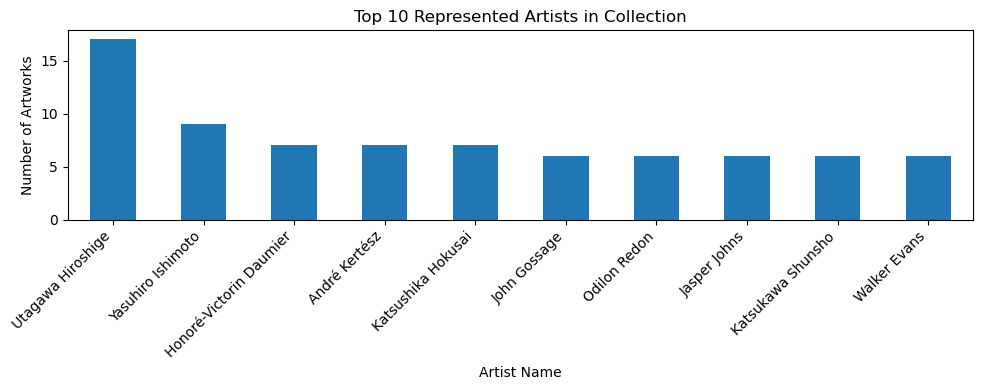

In [20]:
# Remove missing artist names
aic_clean = aic_train.dropna(subset=["artist_title"])

# Remove unknown/unidentified artists
aic_clean = aic_clean[
    ~aic_clean["artist_title"].str.contains("unknown|unidentified|ancient", case=False, na=False)
]

aic_two_name_artists = aic_clean[
    aic_clean["artist_title"].str.split().str.len() == 2
]

top_artists_aic = (
    aic_two_name_artists["artist_title"]
    .value_counts()
    .head(10)
)


top_artists_aic.plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 Represented Artists in Collection")
plt.ylabel("Number of Artworks")
plt.xlabel("Artist Name")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Throughout history, there has been a bias favoring men versus women in the fine arts, explaining the bias in the collection towards men and a sole comapny, Knoll International.**

**Though contemporary works are a small pportion of the museum's collection, it would be valuable to rectify these biases with a more aggressive strategy in acquiring contemporary works, an era more welcoming to women artists.**

**It is also important to note the sheer volume in unknown artists in the collection. Only 13% of the dataset is null with a portion being explictly labeled as unknown or unidentified. This aligns with the museum's dedication to delivering accurate informaiton to visitors, and thus being unwilling to attribute artists when there is not enough information known. However, as mentioned, the museum at times replaces artists names with cultures or ancient civilizations. Standardization in the level of accuracy they deem acceptable could see a drastic shift in the proportion of unknown to known artists.**

### Met

### Century Analysis

**Using the previously formed century labels, we can plot and view the distribution of centuries for works in the Met.**

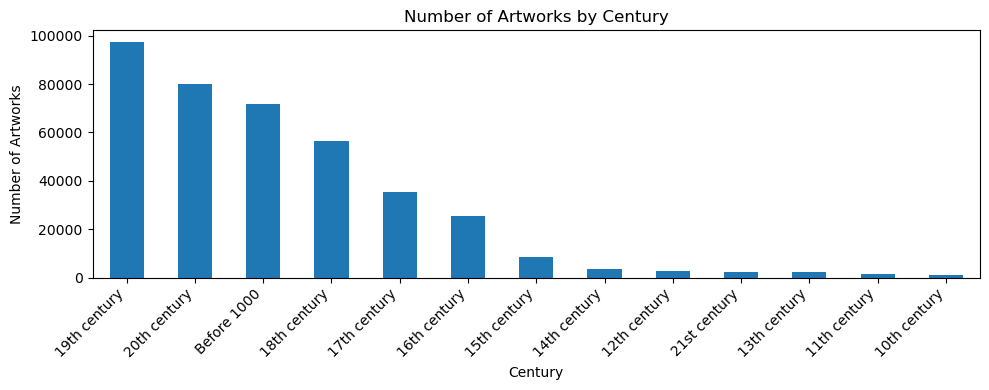

In [21]:
met_train["century_label"].value_counts().plot(kind="bar", figsize=(10,4))
plt.title("Number of Artworks by Century")
plt.ylabel("Number of Artworks")
plt.xlabel("Century")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**The 20th and 19th centuries had pivotal art movements transpire (Modern Art, Impressionism, Rise in photography), explaining their dominant presence in the Met's collection. The following years in the graph hold other important art and cultural movements, adding to the Met's standing as an institution upholding art history. Most interestingly is the dramatic proportional presence of 21st century art in the Met vs. the AIC, which suggests a stronger recent emphasis on collecting or cataloging contemporary works within the AIC’s holdings.**

**Also, the Met comparitively has far less works without specific dates attributed to them. The Met is a larger museum likely with more resources and teams capable of making more specific findings in the works in the collection. Their attitudes in categorizing works may also be more lax than the AIC, leading to much more of their collection being dated than not.**

### Places of Origin

**The previously created origin_normalized column allows for more thorough analization of the origins of works.**

In [22]:
met_train["origin_normalized"].value_counts(normalize=True).head(10)

origin_normalized
United States     0.393129
France            0.190823
United Kingdom    0.112281
Italy             0.100588
Germany           0.049848
Netherlands       0.039916
Japan             0.029627
Spain             0.010638
China             0.009171
Austria           0.008930
Name: proportion, dtype: float64

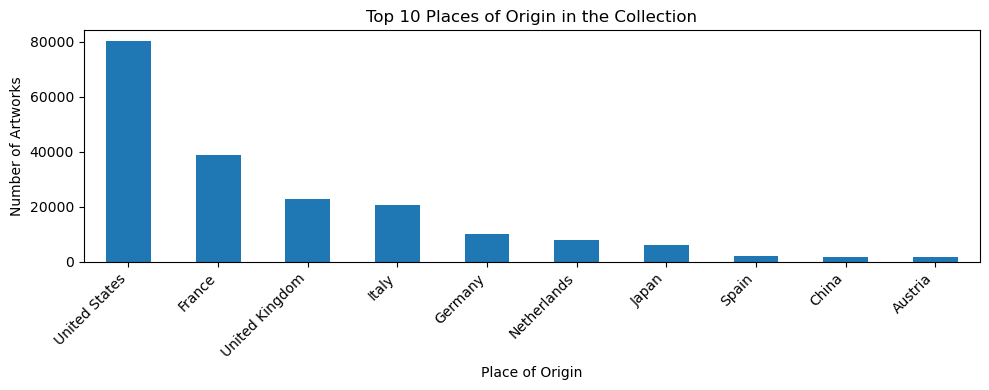

In [23]:
top_places = met_train["origin_normalized"].value_counts().head(10)

top_places.plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 Places of Origin in the Collection")
plt.ylabel("Number of Artworks")
plt.xlabel("Place of Origin")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**As expected, due their historical dominance in the fine arts, the United States, France, and United Kingdom make up the largest portions of the Met's collection. As an American art institution, it is logical that a large portion of the museum's. works are from American artists due to the ease in procuring and hosting works. However, the museum prides itself in showing glimpses of the vast historical legacy of art. It reveals gaps and biases in their displays of works with the dominance of Western cultures in their collection.**

**The specific method in presenting this data also reveals gaps in research. In extracting origin based on nationality, it biases against cultures and regions with less clear documentation on artists such as Ancient Civilizations and non-Western cultures. Works from these regions are likely inherited through private institutions, and potentially procured in damaging ways as there are many non-Western cultures participating in initiatives in re-obtaining culturally significant works. To promote ethics and diversity, it would be worthwhile for the Met to kickstart more initiatives in ethically owning and presenting works from non-Western nations.**

### Most Represented Artists

**Unlike the AIC, the Met avoids replacing artist's names with general cultures and regions to generalize who they can be attributed to. The 'Artist Display Name' has a mixture of individual artists and companies that manufactured different artworks.**

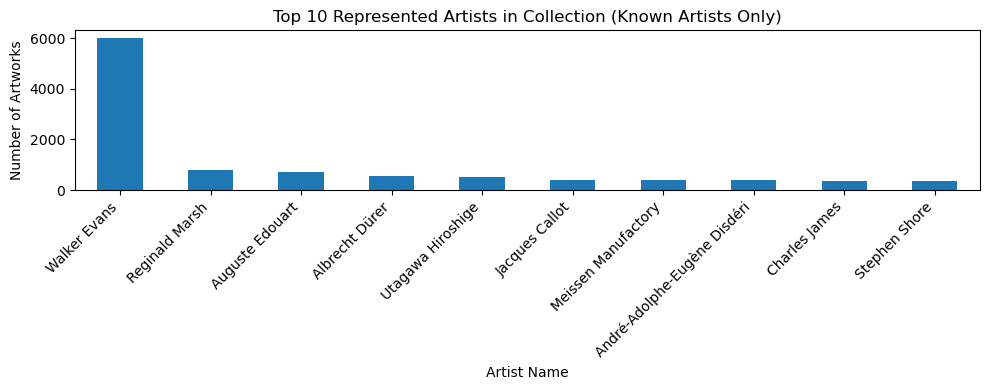

In [24]:
# Remove missing artist names
met_clean = met_train.dropna(subset=["Artist Display Name"])

# Remove unknown/unidentified artists
met_clean = met_clean[
    ~met_clean["Artist Display Name"].str.contains("unknown|unidentified", case=False, na=False)
]

met_two_name_artists = met_clean[
    met_clean["Artist Display Name"].str.split().str.len() == 2
]

top_artists_met = (
    met_two_name_artists["Artist Display Name"]
    .value_counts()
    .head(10)
)


top_artists_met.plot(kind="bar", figsize=(10, 4))
plt.title("Top 10 Represented Artists in Collection (Known Artists Only)")
plt.ylabel("Number of Artworks")
plt.xlabel("Artist Name")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Similarly to the AIC, the Met's most represented artists are all men, or manufacturies as is the case of Meissen Manufactory. Because of the museum's focus on non-contemporary works, their collection derives works from eras where women were less represented and appreciated in the fine arts.**

**In this particular graph, the sheer volume of works by Walker Evans over other artists is due to the Met holding his entire archive of photographs, inherited in 1994. The collection holds tens of thousands of pieces.**

**As discovered earlier, almost half of the Met's collection have unattributed artists. With the Met's focus on older works, this naturally leads to difficulty in finding the original creators of artworks. Such gaps in research could be useful in examining the Met's acquisition strategy of older works. Is adding more to the collection worthwhile at the risk of requiring more resources to categorize works and eventually label them as more vague than others. And, in furthering research, could it potentially reveal a larger presence of women in the museum's collection?**

## Multivariate Analysis

### Dataset Consolidation

**To discover broader trends across an artwork's categorical descriptions, we will consolidate the two museum's data into one dataframe for multivariate analysis. To accomplish this, we will rename columns from the Met dataset to match those from the AIC's, and we will slightly modify columns to reflect equivalent information.**

In [25]:
# The Met's 'Is Highlight' column is equivalent to the AIC's 'has_not_been_viewed_much' column, just with flipped booleans.
# This function modifies 'Is Highlight's booleans to reflect the same information as the AIC's.
def normalize_highlight(viewership):
    if viewership == False:
        return True

    else:
        return False

In [26]:
combine_temp_met = met_train.rename(columns={'Object ID': 'id', 'Title': 'title', 'Classification':'classification_title', 'Artist Display Name':'artist_title', 'Medium':'medium_display', 'Object Begin Date' : 'date_start', 'Object End Date': 'date_end', 'Department': 'department_title', 'Is Highlight': 'has_not_been_viewed_much'})
combine_temp_aic = aic_train.rename(columns={'fiscal_year': 'AccessionYear'})

met_train["Is Highlight"].apply(normalize_highlight)

combine_temp_aic = combine_temp_aic.drop('is_on_view', axis=1)
combine_temp_met = combine_temp_met.drop(['Artist Nationality','Object Name'], axis=1)

In [27]:
combined_df = pd.concat([combine_temp_aic, combine_temp_met])
combined_df.to_csv("combined_artworks.csv", index=False) # Used to create csv for SQL queries

In [28]:
combined_df.info()

<class 'pandas.DataFrame'>
Index: 389233 entries, 867 to 121958
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        389233 non-null  int64  
 1   title                     366263 non-null  str    
 2   has_not_been_viewed_much  389233 non-null  bool   
 3   artist_title              227123 non-null  str    
 4   artist_display            1266 non-null    str    
 5   classification_title      326184 non-null  str    
 6   artwork_type_title        1240 non-null    str    
 7   department_title          389165 non-null  str    
 8   medium_display            383399 non-null  str    
 9   date_display              1262 non-null    str    
 10  date_start                389152 non-null  float64
 11  date_end                  389163 non-null  float64
 12  AccessionYear             385662 non-null  object 
 13  place_of_origin           1171 non-null    str    
 14  or

**The previously created museum column is key in differentiating works by institution.**

In [29]:
combined_df.head()

,id,title,has_not_been_viewed_much,artist_title,artist_display,classification_title,artwork_type_title,department_title,medium_display,date_display,date_start,date_end,AccessionYear,place_of_origin,origin_normalized,century_num,century_label,museum
867,74026,"Garry Winogrand and Melissa, Los Angeles, Cali...",True,Tom Harney,"Tom Harney\nAmerican, born 1946",salted paper print,Photograph,Photography and Media,Gelatin silver print,1979,1979.0,1979.0,1989.0,United States,United States,20.0,20th century,AIC
1018,215359,Setsugo (Joining Together)—A,True,Hamanishi Katsunori,"Hamanishi Katsunori\nJapanese, born 1949",print,Print,Arts of Asia,Mezzotint,1978,1978.0,1978.0,2013.0,Japan,Japan,20.0,20th century,AIC
654,132090,Bottle,True,Ancient Roman,Roman; Levant or Syria,bottle,Vessel,"Arts of Greece, Rome, and Byzantium","Glass, blown technique",2nd-3rd century,101.0,300.0,1945.0,Syria,Syria,2.0,Before 1000,AIC
1049,186925,Arnold Toynbee,True,Yousuf Karsh,"Yousuf Karsh\nCanadian, born Turkish Armenia, ...",gelatin silver print,Photograph,Photography and Media,Gelatin silver print,1955,1955.0,1955.0,2014.0,Canada,Canada,20.0,20th century,AIC
277,146017,Sea Horse,True,Harold Eugene Edgerton,"Harold Eugene Edgerton\nAmerican, 1903–1990",gelatin silver (developing-out-paper) pr,Photograph,Photography and Media,Gelatin silver print,1939,1939.0,1939.0,1997.0,United States,United States,20.0,20th century,AIC


### Accession Year

**Accession year provides insight into when artworks were formally acquired by a museum, offering a lens into institutional collecting priorities over time. By examining the distribution of accession years within the dataset, we can identify periods of increased acquisition activity, potential shifts in collecting strategy, and moments when museums expanded their holdings in particular areas.**

In [30]:
accession_summary = (
    combined_df.groupby("museum")["AccessionYear"]
      .describe()
)
accession_summary.head()

,count,unique,top,freq
museum,,,,
AIC,813.0,100.0,2023.0,51.0
Met,384849,176,1963,33387


In [31]:
# Takes AccessionYear and normalizes dates to be integers rather than a mixture of integers, floats, and strings
def normalize_accession(date):

    if pd.isna(date):
        return None
    
    if type(date) is not float:
        parts = [x.strip() for x in re.split(r'\s*[- .]\s*', date) if x.strip()]
        date = parts[0]

    return int(date)


combined_df["Year Accessed"] = combined_df["AccessionYear"].apply(normalize_accession)

In [32]:
combined_df['Year Accessed'].value_counts()

Year Accessed
1963.0    33391
2011.0    14897
1917.0    10102
1994.0     8449
2009.0     7488
          ...  
1877.0        8
2024.0        7
1872.0        4
2025.0        3
1878.0        1
Name: count, Length: 155, dtype: int64

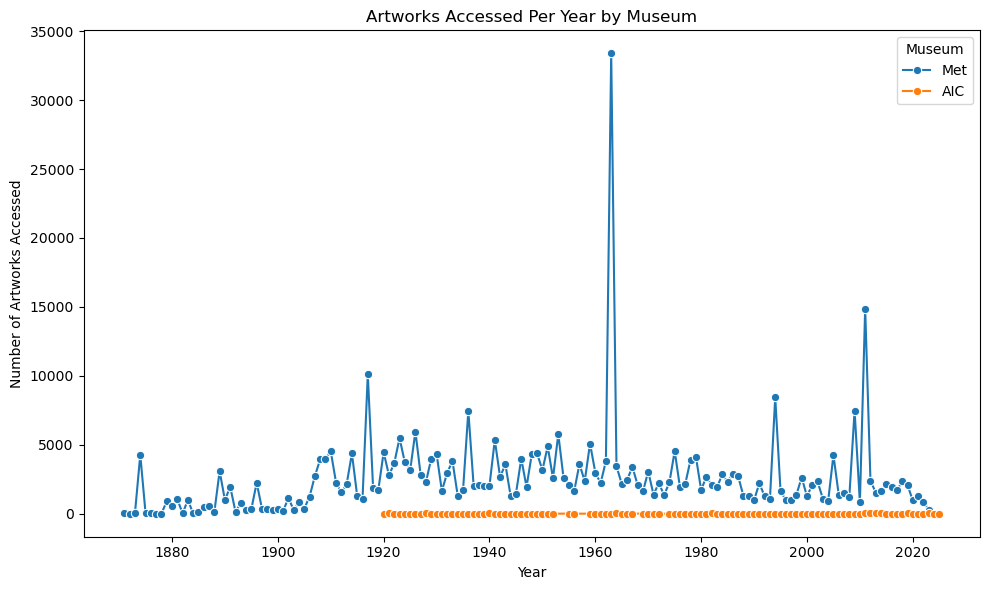

In [33]:
year_counts = (
    combined_df
    .groupby(['Year Accessed', 'museum'])
    .size()
    .reset_index(name='artworks_accessed')
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=year_counts,
    x='Year Accessed',
    y='artworks_accessed',
    hue='museum',
    marker='o'
)

plt.title('Artworks Accessed Per Year by Museum')
plt.xlabel('Year')
plt.ylabel('Number of Artworks Accessed')
plt.legend(title='Museum')

plt.tight_layout()
plt.show()

**Viewing the museum's patterns of procuring works side by side, the Met is more aggressive in its rate of obtaining works to be part of their collection. They hit several more peaks in procuring artworks coinciding with dates when they would create new exhibits and inherent large collections of works from deceased artists and generous donators. The Met naturally has more capacity in collecting work than the AIC due to its sheer size difference. However, it is interesting how much more even and consistent the AIC is with adding to its collection. There is a slight increase in recent years, but overall the museum is less likely to inherit large bodies of work.**

**As research institutions in addition to art museum's, such data is incredibly relevant in making up strategies in furthering research. Inheriting too much art at once can cause too much stress on research teams, especially when accuracy in categorizing art is so important. It is thus important that each museum is careful in slowing down accession in recent years, but they should be incredibly mindful in order to develop effective strategies for the future.**

**Query 6 (Side-by-Side Museum Comparison by Time Period) and Query 7 (Running Total of Artworks Over Time) can be cited alongside this line chart. Query 6 supports the year-by-year comparison directly, while Query 7 helps show whether one museum's lead comes from a steady cumulative buildup over time or from sharper jumps in specific periods.**

### Origin x Century x Classification

**This heatmap examines three variables at once:** origin/culture, century, and artwork classification. **Each panel represents one of the most common classifications, while the color intensity shows how many artworks fall into each origin-century combination.**

**This graph is useful because it moves beyond simple overall counts. It shows whether certain cultures are represented mainly in specific time periods and whether that pattern changes depending on the type of artwork. In other words, it helps determine whether cultural representation is broad across the collection or concentrated within a few historical periods and classifications.**

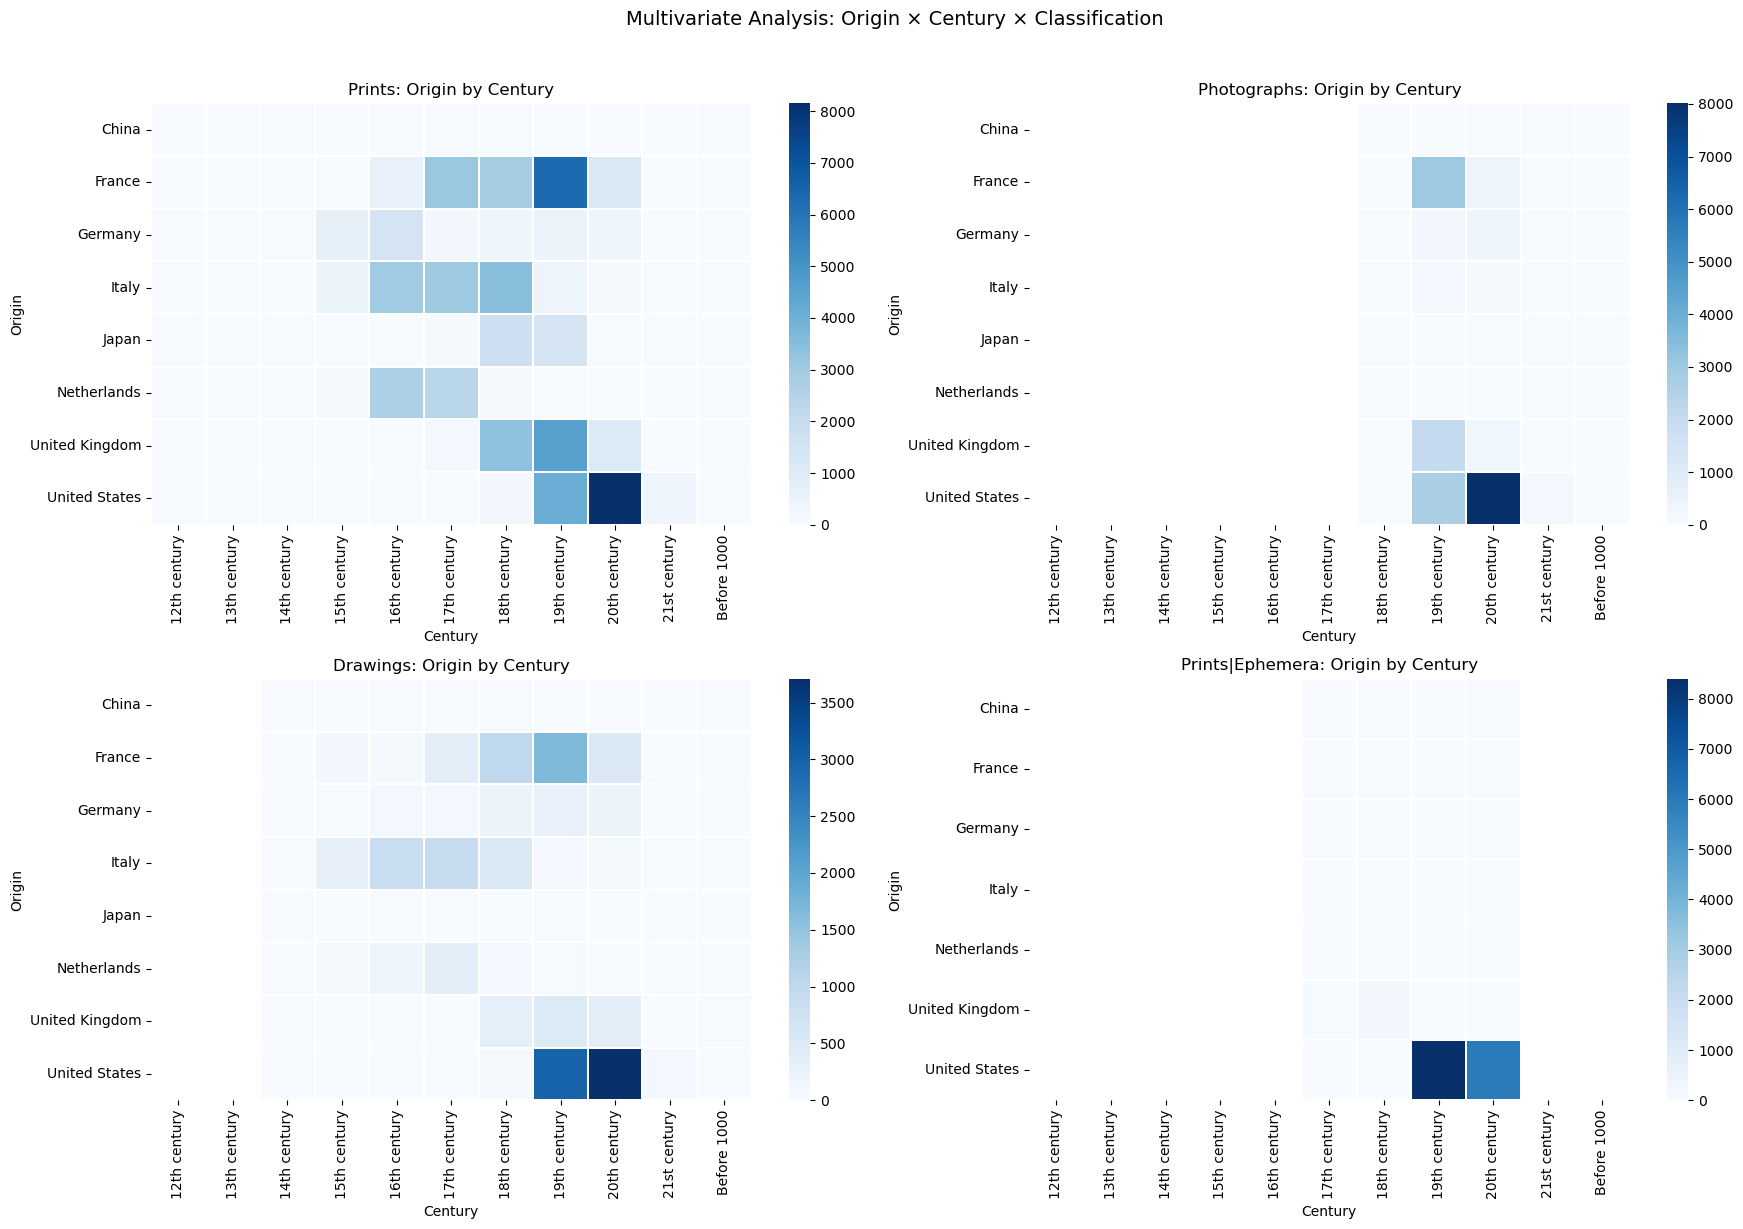

In [34]:
mv1_df = combined_df.copy()
mv1_df = mv1_df[
    mv1_df["origin_normalized"].notna() &
    mv1_df["century_label"].notna() &
    mv1_df["classification_title"].notna()
].copy()

# Keep only top categories so the chart stays readable
top_origins = mv1_df["origin_normalized"].value_counts().head(8).index
top_classifications = mv1_df["classification_title"].value_counts().head(4).index

mv1_df = mv1_df[
    mv1_df["origin_normalized"].isin(top_origins) &
    mv1_df["classification_title"].isin(top_classifications)
].copy()


mv1_counts = (
    mv1_df.groupby(["classification_title", "origin_normalized", "century_label"])
    .size()
    .reset_index(name="artwork_count")
)

# Sort centuries
def century_sort_key(label):
    if pd.isna(label):
        return 9999
    match = re.search(r"(\d+)", str(label))
    return int(match.group(1)) if match else 9999

century_order = sorted(
    mv1_counts["century_label"].dropna().unique(),
    key=century_sort_key
)


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, classification in zip(axes, top_classifications):
    temp = mv1_counts[mv1_counts["classification_title"] == classification]
    pivot = temp.pivot(
        index="origin_normalized",
        columns="century_label",
        values="artwork_count"
    ).fillna(0)

    pivot = pivot.reindex(columns=century_order)

    sns.heatmap(pivot, cmap="Blues", linewidths=0.3, ax=ax)
    ax.set_title(f"{classification}: Origin by Century")
    ax.set_xlabel("Century")
    ax.set_ylabel("Origin")

plt.suptitle("Multivariate Analysis: Origin × Century × Classification", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**This heatmap shows that the museum’s collection is not evenly distributed across origin, century, and classification, but is concentrated in a few very specific clusters. Prints are heavily concentrated in 18th- and especially 19th-century France, the United Kingdom, and the United States, while drawings show a similar but slightly broader spread, with strong representation from France and Italy before shifting toward the United States in the 19th and 20th centuries. Photographs and prints|ephemera are more modern and overwhelmingly U.S.-dominated, with their strongest intensity in the 19th and especially 20th centuries, which suggests these categories are tied  closely to modern mass reproduction and archival collecting practices than to older fine-art traditions. The main conclusion to be drawn is that classification is closely tied to historical period and geography: older European origins dominate traditional works on paper, while newer U.S.-centered holdings dominate modern reproducible media.**

 **Query 3 and Query 5 support this figure by counting origin-by-time and classification-by-time combinations directly. That SQL output can show that the darker visual clusters are backed by grouped counts rather than just visual impression.**

### Date Distribution by Classification and Origin

**This boxplot analyzes** classification, artwork start year, and origin/culture **together. Each box shows the time distribution for a classification, while the color breaks that classification into major origins.**

**This graph is useful because it shows more than how many works exist. It helps reveal the historical spread of each classification and whether certain origins are concentrated in older or newer periods within the same object type. This can show whether representation differs not only in volume, but also in historical depth.**

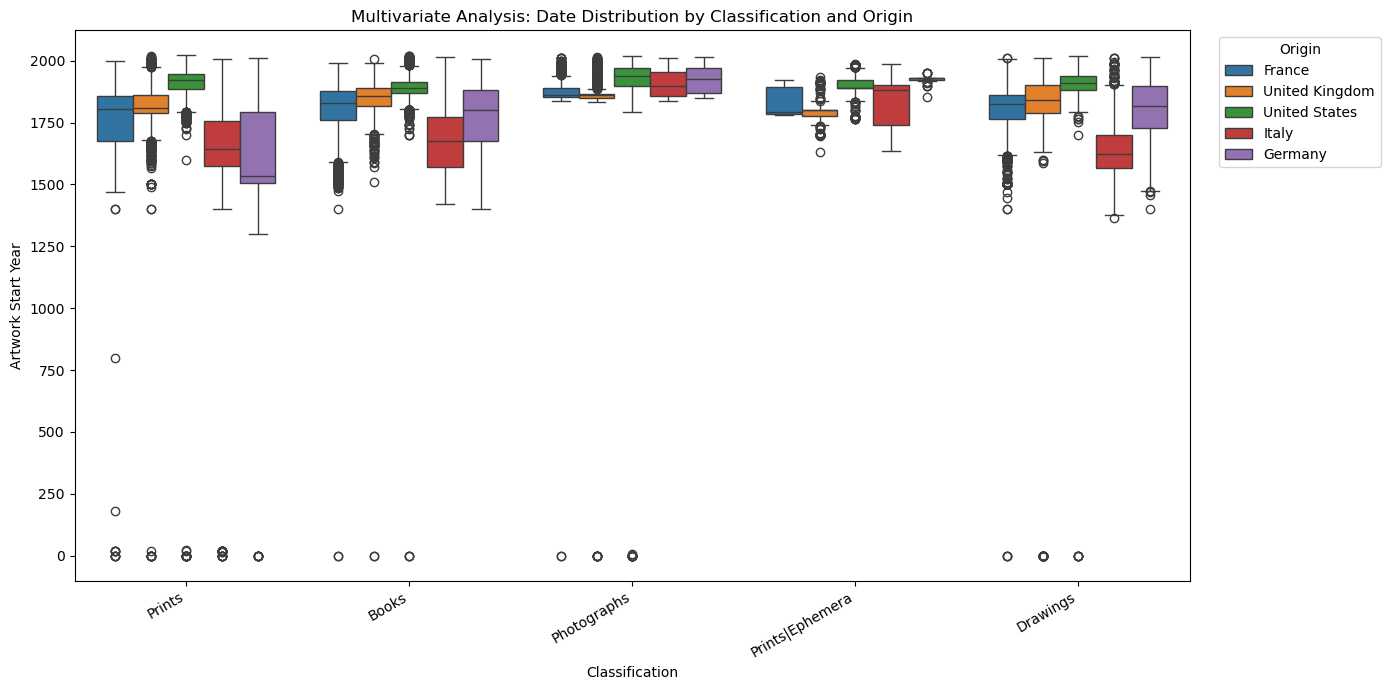

In [35]:
mv2_df = combined_df.copy()
mv2_df = mv2_df[
    mv2_df["classification_title"].notna() &
    mv2_df["date_start"].notna() &
    mv2_df["origin_normalized"].notna()
].copy()

# Keep most common categories for readability
top_classifications = mv2_df["classification_title"].value_counts().head(5).index
top_origins = mv2_df["origin_normalized"].value_counts().head(5).index

mv2_df = mv2_df[
    mv2_df["classification_title"].isin(top_classifications) &
    mv2_df["origin_normalized"].isin(top_origins)
].copy()

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=mv2_df,
    x="classification_title",
    y="date_start",
    hue="origin_normalized"
)

plt.title("Multivariate Analysis: Date Distribution by Classification and Origin")
plt.xlabel("Classification")
plt.ylabel("Artwork Start Year")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Origin", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**This boxplot shows that artwork dates vary across both classification and origin, with photographs and prints|ephemera concentrated much later in time than prints, books, and drawings. The United States has some of the most recent median dates across nearly every category, especially in photographs and drawings, which suggests the museum’s U.S. holdings are heavily weighted toward modern works. Italy tends to have the oldest distributions, particularly in prints, books, and drawings;this indicates stronger representation of earlier material. France and the United Kingdom generally sit in the middle with broad but slightly newer date ranges. The wide spread and numerous outliers in prints and drawings also suggest these categories span a much longer historical window, whereas photographs are more tightly clustered in the late 19th and 20th centuries, reflecting the medium’s later emergence and more concentrated period of production.**

 **Query 12 complements this graph by pairing origin-level counts with average start year, which gives a numeric check on whether large groups also skew earlier or later in time.**

### Origin, Medium, and Artwork Count

**This bubble chart examines** origin/culture, medium, and artwork count **in one figure. Each point represents an origin-medium combination, and the bubble size reflects how many artworks fall into that pairing.**

**This graph is helpful because it shows whether certain cultures are represented through a wide variety of mediums or are concentrated in a smaller number of forms. A larger bubble indicates a stronger relationship between a given origin and medium, while smaller bubbles suggest more limited representation.**

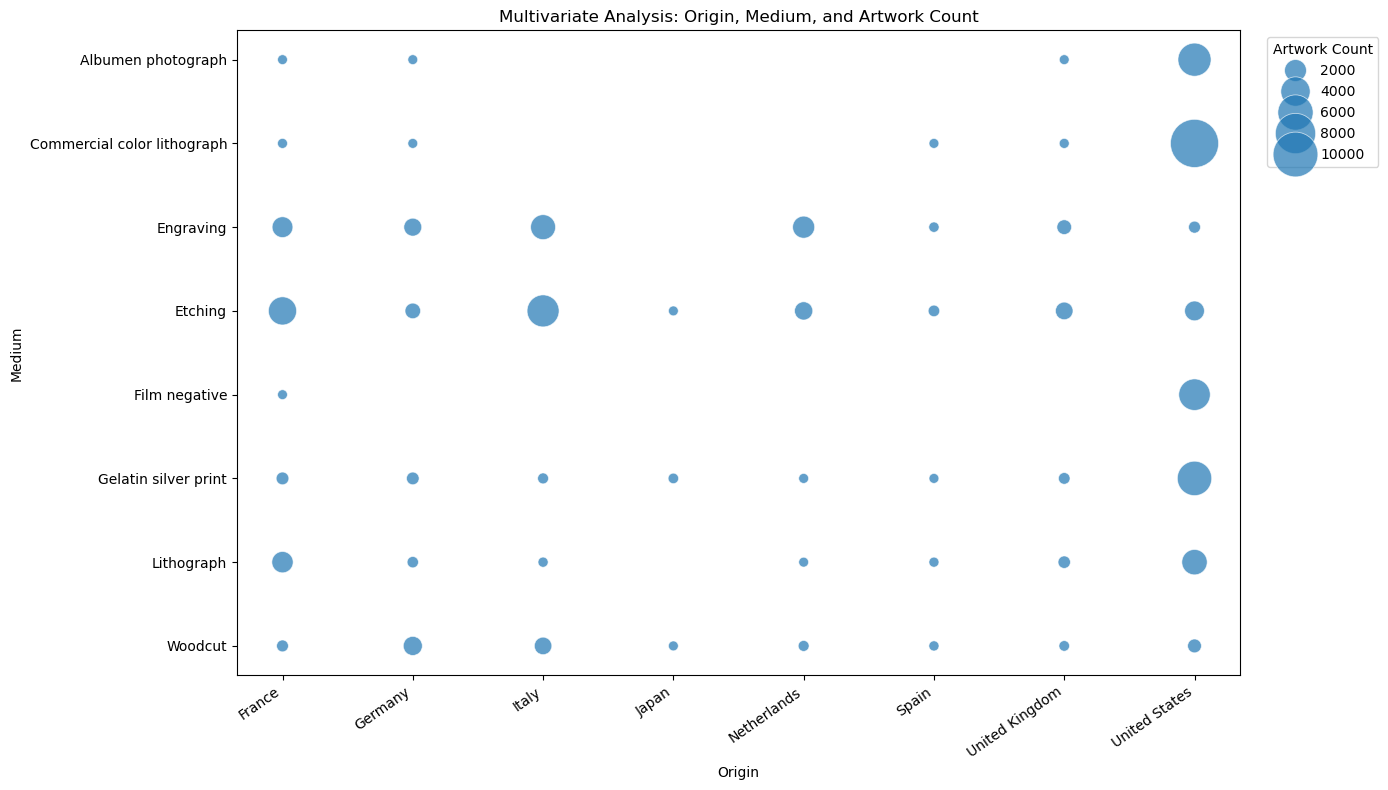

In [36]:
mv3_df = combined_df.copy()
mv3_df = mv3_df[
    mv3_df["origin_normalized"].notna() &
    mv3_df["medium_display"].notna()
].copy()


top_origins = mv3_df["origin_normalized"].value_counts().head(8).index
top_mediums = mv3_df["medium_display"].value_counts().head(8).index

mv3_df = mv3_df[
    mv3_df["origin_normalized"].isin(top_origins) &
    mv3_df["medium_display"].isin(top_mediums)
].copy()

bubble_counts = (
    mv3_df.groupby(["origin_normalized", "medium_display"])
    .size()
    .reset_index(name="artwork_count")
)

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=bubble_counts,
    x="origin_normalized",
    y="medium_display",
    size="artwork_count",
    sizes=(50, 1200),
    alpha=0.7
)

plt.title("Multivariate Analysis: Origin, Medium, and Artwork Count")
plt.xlabel("Origin")
plt.ylabel("Medium")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Artwork Count", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**This bubble chart illustrates that artwork counts are concentrated in specific origin-medium pairings rather than being evenly distributed across countries. The United States stands out clearly in modern photographic and printed media, with large counts in commercial color lithographs, gelatin silver prints, albumen photographs, and film negatives. This suggests the collection has strong depth in reproducible and photography-related U.S. material. In contrast, France and Italy are more strongly associated with traditional printmaking media such as etching and engraving, indicating heavier representation in older European works on paper. Countries like Germany, the Netherlands and Japan appear more selective and narrower in medium concentration. Overall, the main takeaway is that origin helps explain not just how much material the museum holds, but also what type of material dominates each national grouping: the U.S. is strongest in modern image-based media, while continental Europe is more concentrated in historical print techniques.**

**Query 4 and Query 11 are used alongside this chart to show which origins dominate particular object categories and where the two museums diverge most in representation.**

## Regression

### Regression Model 1: Predicting Origin from Century and Medium

**In this model, we try to predict the origin (country or region) of an artwork using two variables from the dataset:**

*• the century the artwork was created*

*• the medium (the material or artistic format)*

**The goal of this model is not to build a perfect prediction model. Instead, we want to test whether basic characteristics of artworks (such as when they were made and what they are made of) contain meaningful signals about where they were produced. To prepare the data, we first created a training dataset from our merged dataframe. Missing values for origin, century, and medium were filled with "Unknown" so that we would not lose those observations. Because there are many different origins and mediums in the dataset, we simplified the categories by keeping only the **10 most common origins and mediums** and grouping all other values into "Other".**

**Next, we converted the categorical variables into numeric variables using one-hot encoding (`pd.get_dummies`), which allows the logistic regression model to use them as inputs. The model uses the following:**

*Features (X):*

*• century_label*

*• medium_reduced*

*Target (y):*

*• origin_reduced*

**We then trained a logistic regression model using the saga solver and class_weight="balanced" to help account for differences in the number of artworks across origins. Finally, the model was evaluated on a test dataset to measure how well it could predict the origin of artworks it had not seen before.**

In [37]:
train_model_df = combined_df.copy()

train_model_df["origin_normalized"] = train_model_df["origin_normalized"].fillna("Unknown")
train_model_df["century_label"] = train_model_df["century_label"].fillna("Unknown")
train_model_df["medium_display"] = train_model_df["medium_display"].fillna("Unknown")

top_mediums = train_model_df["medium_display"].value_counts().head(10).index
top_origins = train_model_df["origin_normalized"].value_counts().head(10).index

train_model_df["medium_reduced"] = train_model_df["medium_display"].where(
    train_model_df["medium_display"].isin(top_mediums),
    "Other"
)

train_model_df["origin_reduced"] = train_model_df["origin_normalized"].where(
    train_model_df["origin_normalized"].isin(top_origins),
    "Other"
)

train_model_df = train_model_df[train_model_df["origin_reduced"] != "Other"].copy()

In [38]:
X_train = pd.get_dummies(
    train_model_df[["century_label", "medium_reduced"]],
    drop_first=False
)

y_train = train_model_df["origin_reduced"]

X_train.shape, y_train.value_counts().head(10)

((375976, 25),
 origin_reduced
 Unknown           184261
 United States      80523
 France             39050
 United Kingdom     22962
 Italy              20551
 Germany            10201
 Netherlands         8173
 Japan               6170
 Spain               2180
 China               1905
 Name: count, dtype: int64)

In [39]:
combine_test_met = met_test.rename(
    columns={
        "Object ID": "id",
        "Title": "title",
        "Classification": "classification_title",
        "Artist Display Name": "artist_title",
        "Medium": "medium_display",
        "Object Begin Date": "date_start",
        "Object End Date": "date_end",
        "Department": "department_title",
        "Is Highlight": "has_not_been_viewed_much"
    }
)

combine_test_aic = aic_test.rename(columns={"fiscal_year": "AccessionYear"})

combine_test_met["has_not_been_viewed_much"] = combine_test_met["has_not_been_viewed_much"].apply(normalize_highlight)

combine_test_aic = combine_test_aic.drop(columns=["is_on_view"], errors="ignore")
combine_test_met = combine_test_met.drop(columns=["Artist Nationality", "Object Name"], errors="ignore")

combined_test = pd.concat([combine_test_aic, combine_test_met], ignore_index=True, sort=False)

combined_test["origin_normalized"] = combined_test["origin_normalized"].fillna("Unknown")
combined_test["century_label"] = combined_test["century_label"].fillna("Unknown")
combined_test["medium_display"] = combined_test["medium_display"].fillna("Unknown")

combined_test["medium_reduced"] = combined_test["medium_display"].where(
    combined_test["medium_display"].isin(top_mediums),
    "Other"
)

combined_test["origin_reduced"] = combined_test["origin_normalized"].where(
    combined_test["origin_normalized"].isin(top_origins),
    "Other"
)

combined_test = combined_test[combined_test["origin_reduced"] != "Other"].copy()

In [40]:
X_test = pd.get_dummies(
    combined_test[["century_label", "medium_reduced"]],
    drop_first=False
)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = combined_test["origin_reduced"]

X_test.shape, y_test.value_counts().head(10)

((94006, 25),
 origin_reduced
 Unknown           46107
 United States     20310
 France             9649
 United Kingdom     5642
 Italy              5140
 Germany            2554
 Netherlands        1989
 Japan              1553
 Spain               582
 China               480
 Name: count, dtype: int64)

In [41]:
model = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [45]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
y_pred = model.predict(X_test)

metrics_summary = pd.DataFrame(
    {
        "metric": ["accuracy", "weighted_f1", "macro_f1"],
        "value": [
            accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred, average="weighted"),
            f1_score(y_test, y_pred, average="macro"),
        ],
    }
)

metrics_summary

,metric,value
0,accuracy,0.334308
1,weighted_f1,0.408615
2,macro_f1,0.175607


In [46]:
print(classification_report(y_test, y_pred, zero_division=0))

                precision    recall  f1-score   support

         China       0.03      0.20      0.06       480
        France       0.26      0.00      0.00      9649
       Germany       0.02      0.17      0.04      2554
         Italy       0.19      0.07      0.10      5140
         Japan       0.05      0.38      0.09      1553
   Netherlands       0.13      0.89      0.22      1989
         Spain       0.00      0.00      0.00       582
United Kingdom       0.15      0.47      0.23      5642
 United States       0.73      0.29      0.41     20310
       Unknown       0.99      0.43      0.59     46107

      accuracy                           0.33     94006
     macro avg       0.26      0.29      0.18     94006
  weighted avg       0.69      0.33      0.41     94006



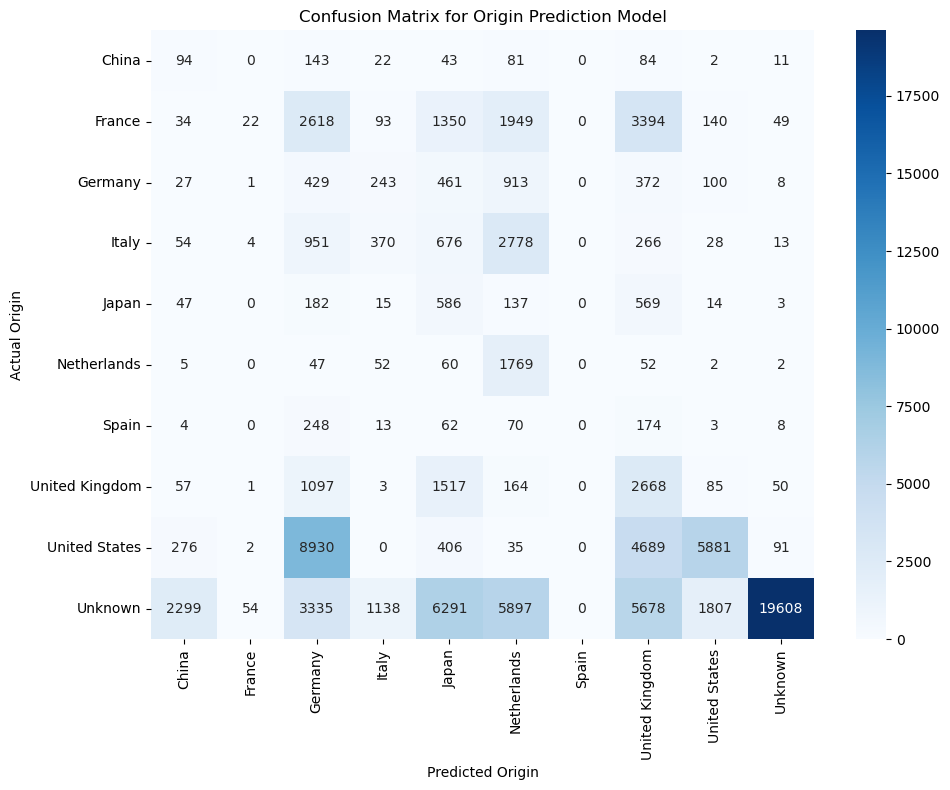

In [48]:
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=model.classes_),
    index=model.classes_,
    columns=model.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Origin Prediction Model")
plt.xlabel("Predicted Origin")
plt.ylabel("Actual Origin")
plt.tight_layout()
plt.show()

**This model does not perform especially well, the overall accuracy is about 33%, which means the model is only correctly predicting the origin about one-third of the time. It suggests that century and medium alone do not provide enough information to reliably determine where an artwork comes from. Many artistic materials and techniques appear across multiple regions of the world, so it makes sense that the model struggles to distinguish between origins using only these two features.**

**Even though the model is not very accurate, it still reveals some interesting patterns in the data. The confusion matrix helps us see where the model is making correct predictions and where it is getting confused.**

**One clear pattern is there are 19,608 correct predictions for "Unknown", which reflects the large number of artworks in the dataset where the origin is missing or unclear. The model also frequently confuses  European countries, particularly France, Germany, Italy, and the United Kingdom. For example, many artworks that are actually from France are predicted as coming from the United Kingdom (3,394 cases). This likely happens because these countries shared many artistic styles and materials during similar historical periods.**

**The United States category performs somewhat better than several others. For example, the model correctly predicts 5,881 artworks from the United States, although it still incorrectly classifies many U.S. artworks as coming from other countries such as Germany or the United Kingdom. Some smaller categories perform more poorly. For example, Spain only has 174 correct predictions, which likely reflects the smaller number of Spanish artworks in the dataset. Overall, the confusion matrix shows that the model occasionally predicts the correct origin, but it often mixes together countries that share similar artistic traditions.**

**The results suggest that **artistic materials and time periods alone are not strong indicators of geographic origin**. Many regions share similar mediums and produce artworks during the same centuries, which makes it difficult for the model to separate them.** 

### Regression Model 2: Predicting Time Period from Origin and Medium

**For our second regression model, we flipped the setup from the first model. Instead of predicting origin, we tried to predict the time period (century) of an artwork using its origin and medium. The idea here is to see whether where an artwork comes from and what it is made of can help us estimate when it was created. In art history, different materials and styles tend to appear in certain time periods, so we wanted to see if the data reflects that pattern.**

**The data preparation steps were very similar to the first regression model. First, we filled missing values for origin, medium, and century with "Unknown" so that those rows would not be dropped from the dataset.**

**Next, because there are many different categories in the data, we simplified the dataset by keeping only the 10 most common origins, mediums, and centuries and grouping the rest into "Other". This helps the model focus on the most common categories instead of trying to learn from very rare ones.**

**Since our goal in this model is to predict the century, we removed rows where the century category became "Other". After that, we converted the categorical variables into numeric variables using dummy variables (pd.get_dummies), which allows the logistic regression model to use them as inputs. The model uses:**

*Features (X):*

*• origin_reduced*

*• medium_reduced*

*Target (y):*

*• century_reduced*

**To make sure the model works properly, we applied the same preprocessing steps to both the training and test datasets so that the variables match between them. We then trained another logistic regression model using the same settings as before. We again used class_weight="balanced" so the model would account for the fact that some centuries appear much more often in the dataset than others.**

In [49]:
train_time_df = combined_df.copy()

train_time_df["origin_normalized"] = train_time_df["origin_normalized"].fillna("Unknown")
train_time_df["century_label"] = train_time_df["century_label"].fillna("Unknown")
train_time_df["medium_display"] = train_time_df["medium_display"].fillna("Unknown")

top_mediums_time = train_time_df["medium_display"].value_counts().head(10).index
top_origins_time = train_time_df["origin_normalized"].value_counts().head(10).index
top_centuries_time = train_time_df["century_label"].value_counts().head(10).index

train_time_df["medium_reduced"] = train_time_df["medium_display"].where(
    train_time_df["medium_display"].isin(top_mediums_time),
    "Other"
)

train_time_df["origin_reduced"] = train_time_df["origin_normalized"].where(
    train_time_df["origin_normalized"].isin(top_origins_time),
    "Other"
)

train_time_df["century_reduced"] = train_time_df["century_label"].where(
    train_time_df["century_label"].isin(top_centuries_time),
    "Other"
)

train_time_df = train_time_df[train_time_df["century_reduced"] != "Other"].copy()

In [ ]:
# This does the same thing your origin model did: fills missing values, keeps only the top 10 mediums, keeps only the top 10 origins

#keeps only the top 10 centuries, collapses the rest into "Other", then removes "Other" from the target so the classifier only predicts the main time groups

In [50]:
X_train_time = pd.get_dummies(
    train_time_df[["origin_reduced", "medium_reduced"]],
    drop_first=False
)

y_train_time = train_time_df["century_reduced"]

X_train_time.shape, y_train_time.value_counts().head(10)

((384471, 22),
 century_reduced
 19th century    97679
 20th century    80719
 Before 1000     71960
 18th century    56509
 17th century    35455
 16th century    25462
 15th century     8389
 14th century     3447
 12th century     2554
 21st century     2297
 Name: count, dtype: int64)

In [51]:
combine_test_met = met_test.rename(
    columns={
        "Object ID": "id",
        "Title": "title",
        "Classification": "classification_title",
        "Artist Display Name": "artist_title",
        "Medium": "medium_display",
        "Object Begin Date": "date_start",
        "Object End Date": "date_end",
        "Department": "department_title",
        "Is Highlight": "has_not_been_viewed_much"
    }
)

combine_test_aic = aic_test.rename(columns={"fiscal_year": "AccessionYear"})

combine_test_met["has_not_been_viewed_much"] = combine_test_met["has_not_been_viewed_much"].apply(normalize_highlight)

combine_test_aic = combine_test_aic.drop(columns=["is_on_view"], errors="ignore")
combine_test_met = combine_test_met.drop(columns=["Artist Nationality", "Object Name"], errors="ignore")

combined_test = pd.concat([combine_test_aic, combine_test_met], ignore_index=True, sort=False)

combined_test["origin_normalized"] = combined_test["origin_normalized"].fillna("Unknown")
combined_test["century_label"] = combined_test["century_label"].fillna("Unknown")
combined_test["medium_display"] = combined_test["medium_display"].fillna("Unknown")

combined_test["medium_reduced"] = combined_test["medium_display"].where(
    combined_test["medium_display"].isin(top_mediums_time),
    "Other"
)

combined_test["origin_reduced"] = combined_test["origin_normalized"].where(
    combined_test["origin_normalized"].isin(top_origins_time),
    "Other"
)

combined_test["century_reduced"] = combined_test["century_label"].where(
    combined_test["century_label"].isin(top_centuries_time),
    "Other"
)

combined_test = combined_test[combined_test["century_reduced"] != "Other"].copy()  # prepare test data

In [52]:
X_test_time = pd.get_dummies(
    combined_test[["origin_reduced", "medium_reduced"]],
    drop_first=False
)

X_test_time = X_test_time.reindex(columns=X_train_time.columns, fill_value=0)
y_test_time = combined_test["century_reduced"]

X_test_time.shape, y_test_time.value_counts().head(10)

((96080, 22),
 century_reduced
 19th century    24539
 20th century    20252
 Before 1000     17984
 18th century    13963
 17th century     8833
 16th century     6318
 15th century     2077
 14th century      853
 12th century      654
 21st century      607
 Name: count, dtype: int64)

In [53]:
time_model = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

time_model.fit(X_train_time, y_train_time)

/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [54]:
y_pred_time = time_model.predict(X_test_time)

metrics_summary_time = pd.DataFrame(
    {
        "metric": ["accuracy", "weighted_f1", "macro_f1"],
        "value": [
            accuracy_score(y_test_time, y_pred_time),
            f1_score(y_test_time, y_pred_time, average="weighted"),
            f1_score(y_test_time, y_pred_time, average="macro")
        ]
    }
)

metrics_summary_time

,metric,value
0,accuracy,0.227175
1,weighted_f1,0.301440
2,macro_f1,0.194116


In [55]:
print(classification_report(y_test_time, y_pred_time, zero_division=0))

              precision    recall  f1-score   support

12th century       0.02      0.96      0.03       654
14th century       0.00      0.00      0.00       853
15th century       0.20      0.04      0.07      2077
16th century       0.36      0.30      0.33      6318
17th century       0.41      0.25      0.31      8833
18th century       0.48      0.03      0.06     13963
19th century       0.58      0.33      0.42     24539
20th century       0.78      0.16      0.26     20252
21st century       0.02      0.84      0.04       607
 Before 1000       0.99      0.26      0.41     17984

    accuracy                           0.23     96080
   macro avg       0.38      0.32      0.19     96080
weighted avg       0.63      0.23      0.30     96080



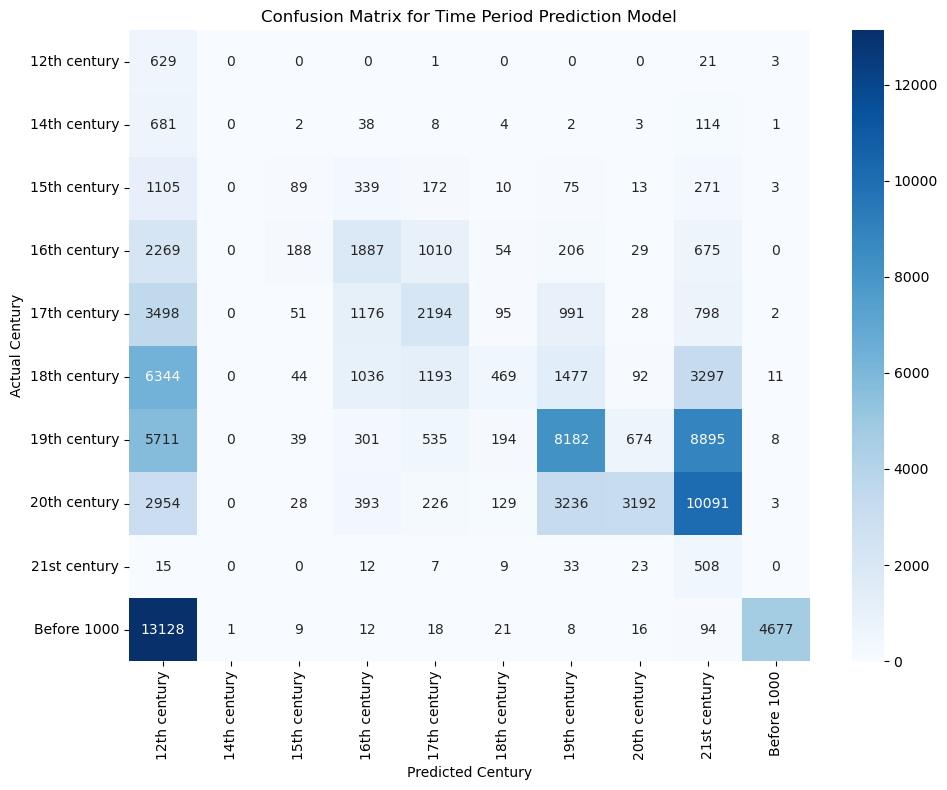

In [56]:
conf_matrix_time = pd.DataFrame(
    confusion_matrix(y_test_time, y_pred_time, labels=time_model.classes_),
    index=time_model.classes_,
    columns=time_model.classes_
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_time, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Time Period Prediction Model")
plt.xlabel("Predicted Century")
plt.ylabel("Actual Century")
plt.tight_layout()
plt.show()

**This model performs somewhat worse than our first regression model that tried to predict origin. The overall accuracy is around 23%, which means the model correctly predicts the century roughly one out of four times.**

**One interesting pattern is that even when the model predicts the wrong century, it often predicts a century that is close to the correct one. For example, artworks from the 18th, 19th, and 20th centuries are often predicted within that same general time range. This suggests that origin and medium still contain some useful information about the historical period in which an artwork was produced. In other words, the materials used and the geographic context of an artwork appear to reflect broader historical trends, even if they are not precise enough to identify the exact century.**

**Looking at the confusion matrix, we can see several patterns in how the model makes predictions. Many artworks from the 19th and 20th centuries are predicted correctly, which is not surprising since these centuries have a large number of artworks in the dataset. For example, the model correctly predicts 8,182 artworks from the 19th century and 10,091 from the 20th century.**

**The "Before 1000" category also stands out, with 13,128 correct predictions, suggesting that very early artworks tend to have distinctive materials or cultural contexts that make them easier for the model to identify. On the other hand, earlier centuries such as the 12th through 15th centuries are harder for the model to separate, likely because there are fewer examples from those time periods in the dataset. These results suggest that medium and time period provide slightly stronger signals for predicting origin than the other way around, while predicting the exact century remains more difficult.**



## Conclusion

### Conclusion
**From this exploratory analysis, we have discovered that there are substantial gaps in representation within the collections we analyzed. A large portion of the artworks in both the Art Institute of Chicago and the Met come from time periods where many of the most well-known art movements were centered in Western nations. Because of this, a lot of the works we see in the datasets come from similar regions and cultural contexts.**

**We also discovered in this EDA how artwork characteristics heavily influence one another. Certain mediums appear more frequently in the collections because they were dominant during the time periods that make up a large portion of the museums’ works. Those same time periods also tend to correspond with particular regions where those movements were most active. As a result, we see patterns where the century, medium, and place of origin are all connected. This helps explain some of the patterns we saw in our regression models as well, where the model was somewhat better at predicting **time period** than predicting **exact geographic origin**.**

**While many of these patterns reflect historical realities of the art world, they also point to larger biases in how art has traditionally been collected, preserved, and studied. Much of this happens behind the scenes, but there is room for museums to collaborate more closely with **art educators and museum educators** to make these gaps more visible to visitors. Instead of presenting collections as a complete picture of art history, museums could help audiences understand how certain cultures, regions, and time periods became more represented than others. Educational programming and interactive exhibits could bring these differences to light and help bring more awareness to the structural biases that exist in the art world.**

**Finally, another takeaway from this EDA is that museums may want to be mindful about the **rate at which works are acquired and cataloged**. Allowing researchers the time and space to study works more deeply could lead to more meaningful scholarship and better documentation. With larger datasets becoming available through open access initiatives, there is also potential for researchers to discover artists who may have been overlooked or misattributed, allowing certain groups (whether based on gender, culture, or historical context) to receive the recognition they deserve.**